# Survival Analysis for Clinical Research
**NC TraCS Technical Tutorials · Time-to-Event Analysis**

This notebook walks through survival analysis — a set of methods that answer a question logistic regression cannot: not just *whether* a clinical event happened, but *when*.

We use a synthetic COVID-19 inpatient cohort. Every technique shown here applies equally to readmission, ICU transfer, time to treatment response, or any clinical outcome where the timing matters.

### What you will learn
1. Why time is a clinically important variable that most models ignore
2. How to define a survival outcome from hospital visit data
3. How to draw and read a Kaplan-Meier survival curve
4. How to test whether two patient groups have different survival patterns
5. How to build a Cox regression model and interpret its hazard ratios
6. How to check that the Cox model's key assumption holds

### What you need beforehand
- Basic familiarity with Python (reading along is enough — you do not need to write code)
- No prior statistics beyond knowing what a p-value means

### Libraries used
```
pandas, numpy, scipy, matplotlib  — all standard, no extra installs needed
```

---
> **Note:** All data is synthetic. No real patient information is included.

## Setup

Run this cell once to load the tools we will use throughout the notebook. Think of it as turning on the equipment before a procedure.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import chi2 as chi2_dist
from scipy.optimize import minimize

# Chart colours used consistently across all figures
plt.rcParams.update({
    'figure.facecolor': '#F7F8FC',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.labelsize':   11,
    'axes.titlesize':   13,
    'font.family':      'sans-serif',
})
TEAL   = '#0E7C86'
NAVY   = '#1A2744'
RED    = '#C94040'
AMBER  = '#E8A045'
GREEN  = '#3A8C5C'
PURPLE = '#5C3D99'

print('Ready.')

Ready.


## 1. Define the Survival Outcome

The first step in any survival analysis is deciding two things:

- **What is the event?** The clinical outcome we are tracking — in this case, in-hospital death.
- **What is the time?** How long each patient was observed before the event occurred.

We restrict to **inpatient COVID-19 visits only**. Outpatient visits have zero or near-zero length of stay and cannot meaningfully contribute to a time-to-event analysis.

| Variable | How it is constructed | What it means |
|----------|-----------------------|---------------|
| `time` | Discharge date minus admission date (minimum 1 day) | How long the patient was observed |
| `event` | Deceased at discharge: 1 = yes, 0 = no | Whether the event (death) was observed |

> **Censoring:** Patients discharged alive are called *censored* — we know they survived at least until discharge, but we do not know what happened after. They are not excluded; they contribute information up to the point they left our observation window.

In [ ]:
# Load the dataset — update the path to match your file location
df = pd.read_csv('data.csv', parse_dates=['visit_start_date', 'visit_end_date'])

# Keep only inpatient COVID-19 visits
inpatient_covid = df[
    (df['visit_type'] == 'Inpatient Visit') &
    (df['observation_source'] == 'Suspected COVID-19')
].copy()

# ── Core survival variables ───────────────────────────────────────
# time  = length of stay in days (floor at 1 to avoid zero-day visits)
# event = 1 if patient died during admission, 0 if discharged alive (censored)
inpatient_covid['time']  = (
    inpatient_covid['visit_end_date'] - inpatient_covid['visit_start_date']
).dt.days.clip(lower=1)

inpatient_covid['event'] = (inpatient_covid['deceased'] == 'Y').astype(int)

# ── Clinical variables we will use as predictors ──────────────────
inpatient_covid['age_group'] = pd.cut(
    inpatient_covid['age_at_visit_years'],
    bins=[-1, 17, 65, 200],
    labels=['Pediatric (<18)', 'Adult (18-65)', 'Elderly (>65)']
)
inpatient_covid['elderly']      = (inpatient_covid['age_at_visit_years'] > 65).astype(int)
inpatient_covid['acute_resp']   = inpatient_covid['condition'].str.contains(
    'Acute respiratory', na=False).astype(int)
inpatient_covid['n_conditions'] = inpatient_covid['condition'].str.count(':').fillna(0) + 1
inpatient_covid['high_hr']      = (inpatient_covid['heart_rate_bpm'] > 100).astype(int)

# ── Summary ───────────────────────────────────────────────────────
total    = len(inpatient_covid)
deaths   = inpatient_covid['event'].sum()
censored = (inpatient_covid['event'] == 0).sum()

print(f'Inpatient COVID-19 visits : {total:,}')
print(f'In-hospital deaths        : {deaths:,}  ({deaths/total:.1%})')
print(f'Discharged alive (censored): {censored:,}  ({censored/total:.1%})')
print(f'Median length of stay     : {inpatient_covid["time"].median():.0f} days')
print()
print('Age group breakdown:')
print(inpatient_covid['age_group'].value_counts().to_string())
print()
print('--- What this means ---')
print(f'About 1 in 3 admitted COVID patients died in hospital ({deaths/total:.0%}).')
print('The remaining 2 in 3 were discharged alive and are censored at their discharge date.')

Inpatient COVID-19 visits : 16,474
In-hospital deaths        : 6,006  (36.5%)
Discharged alive (censored): 10,468  (63.5%)
Median length of stay     : 15 days

Age group breakdown:
Adult (18-65)      11040
Elderly (>65)       4606
Pediatric (<18)      828

--- What this means ---
About 1 in 3 admitted COVID patients died in hospital (36%).
The remaining 2 in 3 were discharged alive and are censored at their discharge date.


### Figure 1: Cohort at a glance

Before fitting any model, it is good practice to visualise the data. These three panels show the distribution of length of stay, mortality by age group, and mortality by clinical risk factor.

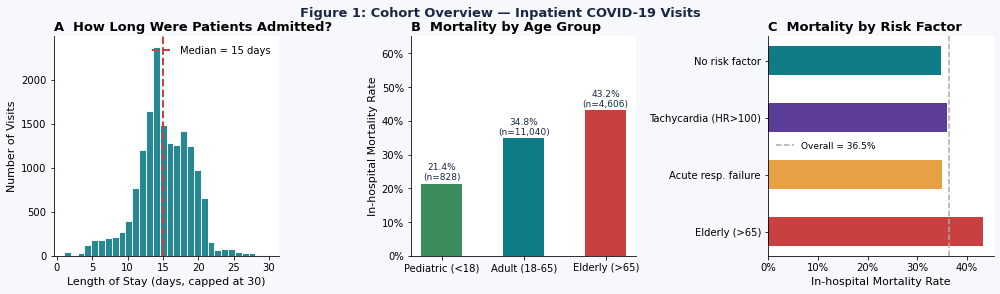

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Panel A: Length-of-stay distribution
ax = axes[0]
los_display = inpatient_covid['time'].clip(upper=30)
ax.hist(los_display, bins=30, color=TEAL, edgecolor='white', alpha=0.9)
ax.axvline(los_display.median(), color=RED, linestyle='--', lw=2,
           label=f'Median = {los_display.median():.0f} days')
ax.set_xlabel('Length of Stay (days, capped at 30)')
ax.set_ylabel('Number of Visits')
ax.set_title('A  How Long Were Patients Admitted?', fontweight='bold', loc='left')
ax.legend(frameon=False)

# Panel B: Mortality by age group
ax = axes[1]
mort_grp = (inpatient_covid.groupby('age_group', observed=True)['event']
            .agg(['mean', 'count']).reset_index())
bars = ax.bar(mort_grp['age_group'], mort_grp['mean'],
              color=[GREEN, TEAL, RED], width=0.5, edgecolor='none')
for bar, (_, row) in zip(bars, mort_grp.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{row['mean']:.1%}\n(n={row['count']:,})",
            ha='center', va='bottom', fontsize=9, color=NAVY)
ax.set_ylabel('In-hospital Mortality Rate')
ax.set_title('B  Mortality by Age Group', fontweight='bold', loc='left')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.set_ylim(0, 0.65)

# Panel C: Mortality by risk factor
ax = axes[2]
overall = inpatient_covid['event'].mean()
feat_mort = {
    'Elderly (>65)':        inpatient_covid.groupby('elderly')['event'].mean()[1],
    'Acute resp. failure':  inpatient_covid.groupby('acute_resp')['event'].mean()[1],
    'Tachycardia (HR>100)': inpatient_covid.groupby('high_hr')['event'].mean()[1],
    'No risk factor':       inpatient_covid[
        (inpatient_covid['elderly']==0) &
        (inpatient_covid['acute_resp']==0)]['event'].mean()
}
ax.barh(list(feat_mort.keys()), list(feat_mort.values()),
        color=[RED, AMBER, PURPLE, TEAL], edgecolor='none', height=0.5)
ax.axvline(overall, color='#AAAAAA', linestyle='--', lw=1.5,
           label=f'Overall = {overall:.1%}')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.set_xlabel('In-hospital Mortality Rate')
ax.set_title('C  Mortality by Risk Factor', fontweight='bold', loc='left')
ax.legend(frameon=False, fontsize=9)

plt.suptitle('Figure 1: Cohort Overview — Inpatient COVID-19 Visits',
             fontsize=13, fontweight='bold', color=NAVY, y=1.01)
plt.tight_layout()
plt.show()

## 2. The Kaplan-Meier Survival Curve

The Kaplan-Meier curve is the most common way to visualise survival data. It plots the probability that a patient has not yet experienced the event (death, in this case) as time passes.

**How to read it:**
- The curve starts at 100% — on admission, no patient has yet died
- It steps downward each time a death occurs
- Between deaths it holds flat — the curve does not interpolate
- A `+` mark indicates a censored patient (discharged alive) — they do not cause a step down
- The shaded band is the 95% confidence interval — it widens over time because fewer patients remain under observation in later days

> **Important note on interpreting this curve:** In this dataset, `time` is the *length of hospital stay*, not prospective follow-up from a fixed calendar date. A patient discharged alive on day 15 is censored at day 15 — so by day 25, the risk set is dominated by long-stay patients, many of whom eventually died. This means S(t) here should be read as: *'the probability of still being admitted and alive at day t'* — not *'the probability of being alive at day t'* from some community starting point. Always state this when presenting the curve.

**The formula** (for reference — you do not need to memorise it):

$$\hat{S}(t) = \prod_{t_i \leq t} \left(1 - \frac{\text{deaths at } t_i}{\text{patients still admitted at } t_i}\right)$$

In [ ]:
def kaplan_meier(times, events):
    """
    Compute the Kaplan-Meier survival function with 95% confidence intervals.

    Confidence intervals use Greenwood's formula on the linear scale,
    clipped to [0, 1]. This is a standard approximation appropriate for
    tutorial purposes.

    Parameters
    ----------
    times  : array-like — follow-up durations
    events : array-like — 1 = event observed, 0 = censored

    Returns
    -------
    DataFrame with columns: time, S (survival probability),
                            lo (lower 95% CI), hi (upper 95% CI),
                            n_risk, n_events
    """
    t = np.array(times,  dtype=float)
    e = np.array(events, dtype=int)

    event_times = np.unique(t[e == 1])  # only times where a death occurred

    rows = [{'time': 0, 'S': 1.0, 'lo': 1.0, 'hi': 1.0,
             'n_risk': len(t), 'n_events': 0}]
    S = 1.0
    greenwood_sum = 0.0

    for ti in sorted(event_times):
        ni = np.sum(t >= ti)               # patients still in hospital at this time
        di = np.sum((t == ti) & (e == 1))  # deaths at this exact time

        S *= (1.0 - di / ni)               # multiply survival probability

        # Greenwood's formula accumulates uncertainty from each death
        if ni > di:
            greenwood_sum += di / (ni * (ni - di))

        se = S * np.sqrt(greenwood_sum)
        rows.append({
            'time':     ti,
            'S':        S,
            'lo':       max(0.0, S - 1.96 * se),
            'hi':       min(1.0, S + 1.96 * se),
            'n_risk':   ni,
            'n_events': di,
        })

    return pd.DataFrame(rows)


def plot_km(km_df, ax, color, label, clip_days=None):
    """Draw a KM step curve with shaded confidence interval."""
    data = km_df.copy()
    if clip_days is not None:
        data = data[data['time'] <= clip_days]
    ax.step(data['time'], data['S'],  where='post', color=color, lw=2.5, label=label)
    ax.fill_between(data['time'], data['lo'], data['hi'],
                    step='post', alpha=0.15, color=color)


print('Kaplan-Meier functions defined.')

Kaplan-Meier functions defined.


### Figure 2: Overall survival curve

We first draw the KM curve for all inpatients combined. The dashed red vertical line marks the **median survival time** — the point at which half of patients still in hospital had experienced the event.

The table printed below the chart shows survival probability at key clinical time points (7, 14, 21, and 28 days). Read this as: *'of patients still admitted at day X, what fraction had not yet died?'

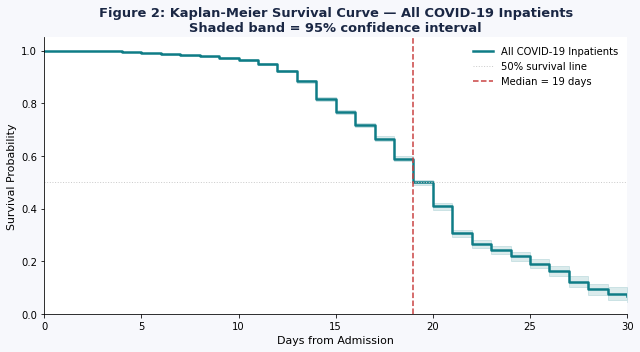

Survival probability at key time points:
  (Read as: of patients still admitted at day X, fraction not yet deceased)

  Day  7: S = 0.982  (95% CI: 0.980 to 0.984)  Deaths so far: 299
  Day 14: S = 0.815  (95% CI: 0.809 to 0.822)  Deaths so far: 2,612
  Day 21: S = 0.306  (95% CI: 0.292 to 0.319)  Deaths so far: 5,796
  Day 28: S = 0.093  (95% CI: 0.072 to 0.115)  Deaths so far: 5,996


In [ ]:
CLIP = 30   # show first 30 days of follow-up

km_all = kaplan_meier(inpatient_covid['time'], inpatient_covid['event'])

# Median survival = first time point where S(t) falls to 0.5 or below
median_rows = km_all[km_all['S'] <= 0.5]
median_t = median_rows['time'].iloc[0] if len(median_rows) else float('inf')

fig, ax = plt.subplots(figsize=(9, 5))
plot_km(km_all, ax, TEAL, 'All COVID-19 Inpatients', clip_days=CLIP)

ax.axhline(0.5, color='#CCCCCC', linestyle=':', lw=1, label='50% survival line')
if not np.isinf(median_t):
    ax.axvline(median_t, color=RED, linestyle='--', lw=1.5,
               label=f'Median = {median_t:.0f} days')

ax.set_xlim(0, CLIP)
ax.set_ylim(0, 1.05)
ax.set_xlabel('Days from Admission')
ax.set_ylabel('Survival Probability')
ax.set_title(
    'Figure 2: Kaplan-Meier Survival Curve — All COVID-19 Inpatients\n'
    'Shaded band = 95% confidence interval',
    fontweight='bold', color=NAVY)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print('Survival probability at key time points:')
print(f'  (Read as: of patients still admitted at day X, fraction not yet deceased)')
print()
for day in [7, 14, 21, 28]:
    row = km_all[km_all['time'] <= day].iloc[-1]
    n_events_so_far = int(km_all[km_all['time'] <= day]['n_events'].sum())
    print(f'  Day {day:>2}: S = {row.S:.3f}  '
          f'(95% CI: {row.lo:.3f} to {row.hi:.3f})  '
          f'Deaths so far: {n_events_so_far:,}')

### Figure 3: Survival by age group

Now we draw separate curves for each age group. Diverging curves indicate that survival experience differs between groups — but we need the log-rank test (next section) to formally assess whether that difference is statistically meaningful.

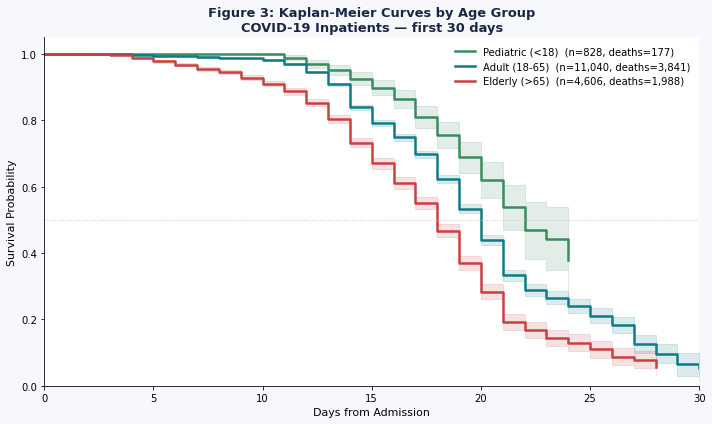

Median survival time by age group:
(First day where S(t) falls to 0.5 or below)

  Pediatric (<18)       : 22 days
  Adult (18-65)         : 20 days
  Elderly (>65)         : 18 days


In [ ]:
groups = [
    ('Pediatric (<18)', inpatient_covid['age_group'] == 'Pediatric (<18)', GREEN),
    ('Adult (18-65)',   inpatient_covid['age_group'] == 'Adult (18-65)',   TEAL),
    ('Elderly (>65)',   inpatient_covid['age_group'] == 'Elderly (>65)',   RED),
]

fig, ax = plt.subplots(figsize=(10, 6))
km_by_group = {}

for label, mask, color in groups:
    sub = inpatient_covid[mask]
    if len(sub) < 10:
        continue
    km = kaplan_meier(sub['time'], sub['event'])
    km_by_group[label] = km
    plot_km(km, ax, color,
            label=f'{label}  (n={mask.sum():,}, deaths={sub["event"].sum():,})',
            clip_days=CLIP)

ax.axhline(0.5, color='#CCCCCC', linestyle=':', lw=1)
ax.set_xlim(0, CLIP)
ax.set_ylim(0, 1.05)
ax.set_xlabel('Days from Admission')
ax.set_ylabel('Survival Probability')
ax.set_title(
    'Figure 3: Kaplan-Meier Curves by Age Group\n'
    'COVID-19 Inpatients — first 30 days',
    fontweight='bold', color=NAVY)
ax.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.show()

print('Median survival time by age group:')
print('(First day where S(t) falls to 0.5 or below)')
print()
for label, km in km_by_group.items():
    med_rows = km[km['S'] <= 0.5]
    med = med_rows['time'].iloc[0] if len(med_rows) else float('inf')
    txt = f'{med:.0f} days' if not np.isinf(med) else 'Not reached within 30 days'
    print(f'  {label:<22}: {txt}')

## 3. Log-Rank Test: Are These Curves Genuinely Different?

Looking at curves that diverge is not enough — we need a formal test to rule out chance. The log-rank test compares survival curves across groups and produces a p-value.

**What it asks:** Could these two survival curves have come from the same underlying population? A small p-value says: probably not — the groups are genuinely different.

**Critical caveat:** The p-value only tells you *whether* the curves differ, not *by how much*. A very large study can produce p < 0.001 even when the difference in median survival is two days. Always report median survival times alongside the p-value.

The formula (for reference):

$$\chi^2 = \frac{(\text{observed deaths in group 1} - \text{expected deaths in group 1})^2}{\text{variance}}$$

In [ ]:
def logrank_test(times_a, events_a, times_b, events_b):
    """
    Two-sample log-rank (Mantel-Cox) test.
    At each death time, compares observed vs. expected deaths in group A.

    Returns
    -------
    chi2_stat : float
    p_value   : float
    """
    ta, ea = np.array(times_a, dtype=float), np.array(events_a, dtype=int)
    tb, eb = np.array(times_b, dtype=float), np.array(events_b, dtype=int)

    all_event_times = np.unique(np.concatenate([ta[ea == 1], tb[eb == 1]]))

    O1 = E1 = V = 0.0
    for t in all_event_times:
        na = np.sum(ta >= t);  da = np.sum((ta == t) & (ea == 1))
        nb = np.sum(tb >= t);  db = np.sum((tb == t) & (eb == 1))
        n  = na + nb;          d  = da + db
        if n < 2:
            continue
        E1 += na * d / n          # expected deaths in group A under H0
        O1 += da                   # observed deaths in group A
        if n > 1 and (n - d) > 0:
            V += na * nb * d * (n - d) / (n**2 * (n - 1))  # variance

    chi2_stat = (O1 - E1)**2 / V if V > 0 else 0.0
    p_value   = 1 - chi2_dist.cdf(chi2_stat, df=1)
    return chi2_stat, p_value


# ── Test 1: Elderly vs non-elderly ───────────────────────────────
eld  = inpatient_covid[inpatient_covid['elderly'] == 1]
neld = inpatient_covid[inpatient_covid['elderly'] == 0]

stat, p = logrank_test(eld['time'], eld['event'], neld['time'], neld['event'])
print('=== Log-Rank Test: Elderly (>65) vs Non-elderly ===')
print(f'  Chi-squared statistic : {stat:.1f}')
print(f'  p-value               : {p:.2e}')
print(f'  Interpretation        : {"Curves are statistically different" if p < 0.05 else "No significant difference"} at alpha = 0.05')
print()

# ── Test 2: Pairwise comparisons across all three age groups ──────
print('=== Pairwise Log-Rank Tests Across Age Groups ===')
print()
group_data = {
    k: inpatient_covid[inpatient_covid['age_group'] == k]
    for k in ['Pediatric (<18)', 'Adult (18-65)', 'Elderly (>65)']
}
keys = list(group_data.keys())
for i in range(len(keys)):
    for j in range(i+1, len(keys)):
        ga, gb = group_data[keys[i]], group_data[keys[j]]
        s, pv = logrank_test(ga['time'], ga['event'], gb['time'], gb['event'])
        sig = '  <- significant' if pv < 0.05 else ''
        print(f'  {keys[i]:<22} vs {keys[j]:<22}: chi2 = {s:>6.1f},  p = {pv:.2e}{sig}')

print()
print('Remember: p < 0.05 tells you IF the curves differ — not by how much.')
print('Always report median survival times alongside the p-value.')

=== Log-Rank Test: Elderly (>65) vs Non-elderly ===
  Chi-squared statistic : 5134.4
  p-value               : 0.00e+00
  Interpretation        : Curves are statistically different at alpha = 0.05

=== Pairwise Log-Rank Tests Across Age Groups ===

  Pediatric (<18)        vs Adult (18-65)         : chi2 = 1371.4,  p = 0.00e+00  <- significant
  Pediatric (<18)        vs Elderly (>65)         : chi2 =  617.3,  p = 0.00e+00  <- significant
  Adult (18-65)          vs Elderly (>65)         : chi2 =    0.0,  p = 1.00e+00

Remember: p < 0.05 tells you IF the curves differ — not by how much.
Always report median survival times alongside the p-value.


## 4. Cox Proportional Hazards Model

The Kaplan-Meier curve and log-rank test compare groups, but they cannot control for other patient characteristics simultaneously. If elderly patients have worse survival, is that because of age itself, or because they also have more comorbidities?

The **Cox model** adjusts for multiple variables at once and produces a **Hazard Ratio (HR)** for each one — a single number expressing that variable's independent contribution to the daily rate of the event.

**How to read a Hazard Ratio:**

| HR value | Meaning |
|----------|---------|
| HR = 1.0 | No effect — this factor is not associated with the event rate |
| HR = 2.0 | Twice the daily risk of the event |
| HR = 0.5 | Half the daily risk |
| HR = 3.5 | 3.5 times the daily risk |

The model formula (for reference):

$$h(t \mid X) = h_0(t) \cdot \exp(\beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_p X_p)$$

where $h_0(t)$ is the baseline hazard (shared by all patients) and $\exp(\beta_i)$ is the hazard ratio for variable $i$.

> **Note on variable selection:** We do not include both continuous age and the elderly binary flag in the same model — they measure the same thing and including both causes numerical instability. We use continuous age as the primary predictor.

In [ ]:
def fit_cox(df, duration_col, event_col, covariate_cols):
    """
    Fit a Cox proportional hazards model via partial likelihood maximisation.
    Covariates are standardised internally for numerical stability, then
    back-transformed so output coefficients are on the original scale.

    Returns
    -------
    DataFrame with columns:
        covariate  : variable name
        coef       : log hazard ratio (on original scale)
        HR         : hazard ratio = exp(coef)
        HR_lo95    : lower 95% confidence limit for HR
        HR_hi95    : upper 95% confidence limit for HR
        se         : standard error of coef
        z          : z-statistic
        p          : two-sided p-value
    """
    df_clean = df[[duration_col, event_col] + covariate_cols].dropna().copy()
    t = df_clean[duration_col].values.astype(float)
    e = df_clean[event_col].values.astype(int)
    X = df_clean[covariate_cols].values.astype(float)

    # Standardise covariates (zero mean, unit SD) for numerical stability
    means = X.mean(axis=0)
    stds  = X.std(axis=0)
    stds[stds == 0] = 1.0
    Xs = (X - means) / stds

    # Sort by ascending follow-up time (required for partial likelihood)
    order = np.argsort(t)
    t, e, Xs = t[order], e[order], Xs[order]

    def neg_log_partial_likelihood(beta):
        """The quantity we minimise to fit the model."""
        xb = Xs @ beta
        ll = 0.0
        for i in range(len(t)):
            if e[i] == 1:
                xb_risk = xb[i:]           # risk set: all patients still present
                m   = xb_risk.max()        # log-sum-exp trick for numerical stability
                lse = m + np.log(np.sum(np.exp(xb_risk - m)))
                ll += xb[i] - lse
        return -ll

    result = minimize(
        neg_log_partial_likelihood,
        x0=np.zeros(Xs.shape[1]),
        method='BFGS',
        options={'maxiter': 500, 'gtol': 1e-6}
    )
    beta_std = result.x

    # Back-transform to original covariate scale
    beta_orig = beta_std / stds

    # Numerical Hessian -> variance -> standard errors
    h = 1e-4
    p = len(beta_std)
    H = np.zeros((p, p))
    for j in range(p):
        for k in range(p):
            ej = np.eye(p)[j] * h
            ek = np.eye(p)[k] * h
            H[j, k] = (
                neg_log_partial_likelihood(beta_std + ej + ek)
                - neg_log_partial_likelihood(beta_std + ej - ek)
                - neg_log_partial_likelihood(beta_std - ej + ek)
                + neg_log_partial_likelihood(beta_std - ej - ek)
            ) / (4 * h * h)

    try:
        var_std  = np.diag(np.linalg.inv(H))
        se_std   = np.sqrt(np.abs(var_std))
        se_orig  = se_std / stds
    except np.linalg.LinAlgError:
        se_std = se_orig = np.full(p, np.nan)

    z  = beta_std / (se_std + 1e-10)
    pv = 2 * (1 - chi2_dist.cdf(z**2, df=1))

    return pd.DataFrame({
        'covariate': covariate_cols,
        'coef':      beta_orig,
        'HR':        np.exp(beta_orig),
        'HR_lo95':   np.exp(beta_orig - 1.96 * se_orig),
        'HR_hi95':   np.exp(beta_orig + 1.96 * se_orig),
        'se':        se_orig,
        'z':         z,
        'p':         pv,
    })


print('Cox model function defined.')

Cox model function defined.


### Fitting the model

We include four predictor variables:

| Variable | What it captures |
|----------|------------------|
| `age_at_visit_years` | Patient age (continuous) |
| `acute_resp` | Acute respiratory failure (yes/no) |
| `n_conditions` | Total number of conditions listed — a severity proxy |
| `high_hr` | Tachycardia, heart rate above 100 bpm (yes/no) |

> **Why not include the elderly flag here?** The elderly variable (age > 65) is derived directly from `age_at_visit_years`. Including both in the same model is like asking two people to answer the same question simultaneously — it causes numerical instability and produces meaningless results. We use continuous age, which captures the full age effect.

In [ ]:
# Variables to include in the Cox model
# Note: we use age_at_visit_years (continuous) and do NOT also include
# the elderly binary flag — they measure the same thing and including
# both causes collinearity that destabilises the numerical estimates.
COX_VARS = ['age_at_visit_years', 'acute_resp', 'n_conditions', 'high_hr']

cox_data = inpatient_covid[['time', 'event'] + COX_VARS].dropna().copy()
print(f'Model dataset: {len(cox_data):,} visits,  {cox_data["event"].sum():,} deaths')
print('Fitting Cox model...')

cox_results = fit_cox(cox_data, 'time', 'event', COX_VARS)

print()
print('=== Cox Proportional Hazards Model Results ===')
print()

# Print in plain-English format
for _, row in cox_results.iterrows():
    sig = '  <-- significant' if row['p'] < 0.05 else ''
    direction = 'higher' if row['HR'] > 1 else 'lower'
    print(f"  {row['covariate']:<25}  HR = {row['HR']:.3f}  "
          f"(95% CI: {row['HR_lo95']:.3f} to {row['HR_hi95']:.3f})  "
          f"p = {row['p']:.3f}{sig}")

print()
print('How to read these results:')
print('  HR > 1 means higher daily risk of death (worse prognosis)')
print('  HR < 1 means lower daily risk of death (protective)')
print('  HR = 1 means no independent association with daily risk')
print('  p < 0.05 means the association is unlikely to be due to chance')

Model dataset: 16,474 visits,  6,006 deaths
Fitting Cox model...

=== Cox Proportional Hazards Model Results ===

  age_at_visit_years         HR = 1.016  (95% CI: 1.015 to 1.018)  p = 0.000  <-- significant
  acute_resp                 HR = 1.124  (95% CI: 1.064 to 1.187)  p = 0.000  <-- significant
  n_conditions               HR = 1.009  (95% CI: 0.992 to 1.025)  p = 0.606
  high_hr                    HR = 0.943  (95% CI: 0.894 to 0.995)  p = 0.063

How to read these results:
  HR > 1 means higher daily risk of death (worse prognosis)
  HR < 1 means lower daily risk of death (protective)
  HR = 1 means no independent association with daily risk
  p < 0.05 means the association is unlikely to be due to chance


### Figure 4: Forest plot

A forest plot is the standard way to display hazard ratios from a Cox model. Each row is one variable. The dot is the hazard ratio estimate; the horizontal line is the 95% confidence interval. If the line crosses the vertical dashed line at HR = 1, the result is not statistically significant.

Diamond shapes indicate variables where p < 0.05.

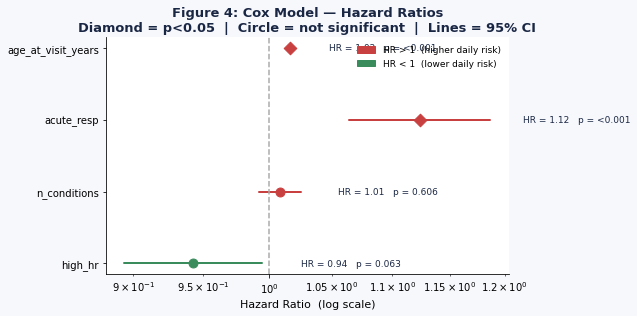

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))

y_pos = range(len(cox_results) - 1, -1, -1)

for yi, (_, row) in zip(y_pos, cox_results.iterrows()):
    color = RED if row['HR'] > 1 else GREEN
    # Confidence interval line
    ax.plot([row['HR_lo95'], row['HR_hi95']], [yi, yi],
            color=color, lw=2, solid_capstyle='round')
    # Point estimate (diamond = significant, circle = not significant)
    marker = 'D' if row['p'] < 0.05 else 'o'
    ax.scatter(row['HR'], yi, color=color, s=80, zorder=5, marker=marker)
    # Label
    p_label = '<0.001' if row['p'] < 0.001 else f"{row['p']:.3f}"
    ax.text(row['HR_hi95'] + 0.03, yi,
            f"HR = {row['HR']:.2f}   p = {p_label}",
            va='center', fontsize=9, color=NAVY)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(cox_results['covariate'].tolist())
ax.axvline(1.0, color='#AAAAAA', linestyle='--', lw=1.5)
ax.set_xlabel('Hazard Ratio  (log scale)', fontsize=11)
ax.set_xscale('log')
ax.set_title(
    'Figure 4: Cox Model — Hazard Ratios\n'
    'Diamond = p<0.05  |  Circle = not significant  |  Lines = 95% CI',
    fontweight='bold', color=NAVY)

patch_hi = mpatches.Patch(color=RED,   label='HR > 1  (higher daily risk)')
patch_lo = mpatches.Patch(color=GREEN, label='HR < 1  (lower daily risk)')
ax.legend(handles=[patch_hi, patch_lo], frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

## 5. Predicted Survival Curves for Individual Patient Profiles

The Cox model can project a survival curve for any specific patient, based on their individual combination of risk factors. This is what makes Cox regression clinically useful: it moves from population-level statistics to patient-level prediction.

We illustrate this with three patient profiles ranging from low to high risk:

| Profile | Age | Acute respiratory failure | Conditions | Tachycardia |
|---------|-----|--------------------------|------------|-------------|
| Low risk | 40 | No | 2 | No |
| Moderate risk | 72 | No | 3 | No |
| High risk | 72 | Yes | 6 | Yes |

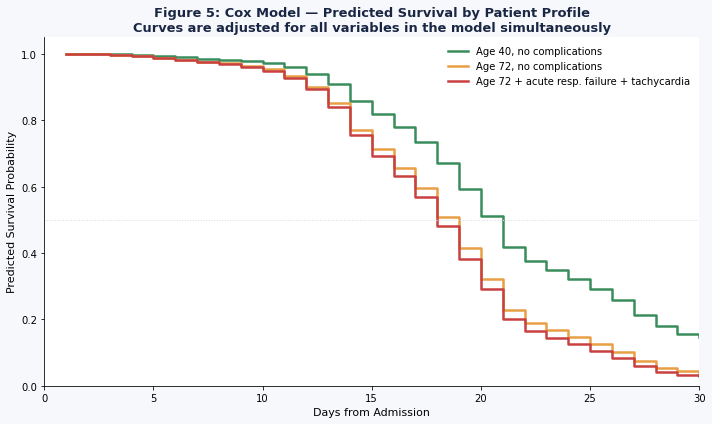

Predicted 14-day survival probability by patient profile:

  Age 40, no complications                     : 85.8%
  Age 72, no complications                     : 77.2%
  Age 72 + acute resp. failure + tachycardia   : 75.5%


In [ ]:
def predict_survival_cox(cox_results, reference_data, duration_col, event_col,
                         covariate_cols, profiles, clip_days=30):
    """
    Predict survival curves for specified patient profiles.
    Uses the Breslow estimator to compute the baseline hazard from training data.
    """
    betas    = dict(zip(cox_results['covariate'], cox_results['coef']))
    ref      = reference_data[[duration_col, event_col] + covariate_cols].dropna().copy()
    t        = ref[duration_col].values
    e        = ref[event_col].values
    X        = ref[covariate_cols].values.astype(float)
    beta_vec = np.array([betas[c] for c in covariate_cols])
    xb       = X @ beta_vec

    # Breslow estimator: cumulative baseline hazard
    event_times = np.unique(t[e == 1])
    H0 = []
    for ti in sorted(event_times):
        risk_set = t >= ti
        di    = np.sum((t == ti) & (e == 1))
        denom = np.sum(np.exp(xb[risk_set]))
        H0.append({'time': ti, 'dh0': di / denom if denom > 0 else 0})
    H0_df         = pd.DataFrame(H0)
    H0_df['H0']   = H0_df['dh0'].cumsum()
    H0_clip       = H0_df[H0_df['time'] <= clip_days].copy()

    # Project survival for each profile
    results = []
    for profile in profiles:
        xb_new = sum(betas[c] * profile[c] for c in covariate_cols)
        S_pred = np.exp(-H0_clip['H0'] * np.exp(xb_new))
        results.append(pd.DataFrame({
            'time': H0_clip['time'].values,
            'S':    S_pred.values
        }))
    return results


profiles = [
    {'age_at_visit_years': 40, 'acute_resp': 0, 'n_conditions': 2, 'high_hr': 0},
    {'age_at_visit_years': 72, 'acute_resp': 0, 'n_conditions': 3, 'high_hr': 0},
    {'age_at_visit_years': 72, 'acute_resp': 1, 'n_conditions': 6, 'high_hr': 1},
]
profile_labels  = [
    'Age 40, no complications',
    'Age 72, no complications',
    'Age 72 + acute resp. failure + tachycardia',
]
profile_colors  = [GREEN, AMBER, RED]

surv_preds = predict_survival_cox(
    cox_results, cox_data, 'time', 'event', COX_VARS, profiles, clip_days=CLIP
)

fig, ax = plt.subplots(figsize=(10, 6))
for pred, label, color in zip(surv_preds, profile_labels, profile_colors):
    ax.step(pred['time'], pred['S'], where='post',
            color=color, lw=2.5, label=label)

ax.axhline(0.5, color='#DDDDDD', linestyle=':', lw=1)
ax.set_xlim(0, CLIP)
ax.set_ylim(0, 1.05)
ax.set_xlabel('Days from Admission')
ax.set_ylabel('Predicted Survival Probability')
ax.set_title(
    'Figure 5: Cox Model — Predicted Survival by Patient Profile\n'
    'Curves are adjusted for all variables in the model simultaneously',
    fontweight='bold', color=NAVY)
ax.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.show()

print('Predicted 14-day survival probability by patient profile:')
print()
for pred, label in zip(surv_preds, profile_labels):
    row = pred[pred['time'] <= 14].iloc[-1] if len(pred[pred['time'] <= 14]) else None
    s = f"{row['S']:.1%}" if row is not None else 'N/A'
    print(f'  {label:<45}: {s}')

## 6. Checking the Proportional Hazards Assumption

The Cox model rests on one important assumption: the hazard ratio for each variable must stay **constant over time**. For example, if being elderly doubles the daily risk of death on day 1, it should also roughly double it on day 14 and day 28.

If this assumption is violated for a variable — meaning its effect on risk changes over time — the hazard ratio the model reports is an average that may not accurately represent what is happening at any particular point in the follow-up.

**How to check it:** We use **Schoenfeld residuals**. For each variable, we compute a residual for every death in the dataset and plot those residuals against time. If the smoothed trend line is flat (no upward or downward slope), the assumption holds. A sloping trend indicates a violation.

> You do not need to understand the mathematics of Schoenfeld residuals to use this check. Just look at the smoothed red line in each panel — flat is good, sloped needs attention.

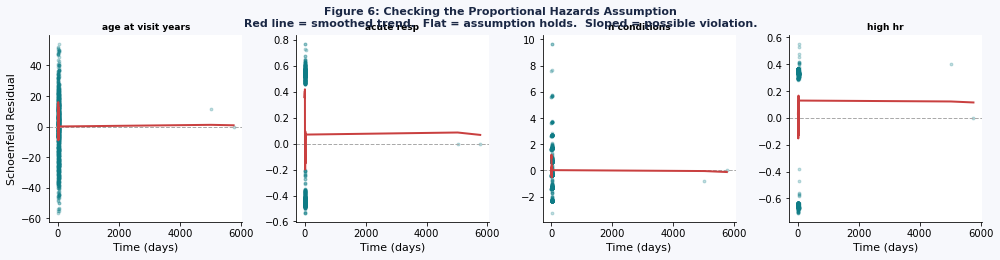

How to interpret these plots:

  Flat red line  -> the proportional hazards assumption likely holds for this variable
  Upward slope   -> the variable has a stronger effect early in the admission
  Downward slope -> the variable has a stronger effect later in the admission

If a slope is present, consider adding a time-varying interaction term
or stratifying the Cox model by that variable.


In [ ]:
def schoenfeld_residuals(df, duration_col, event_col, covariate_cols, cox_res):
    """
    Compute Schoenfeld residuals for each covariate.
    For each death event: residual = observed covariate value minus
    the weighted average of that covariate across the risk set at that time.
    A flat trend over time indicates the proportional hazards assumption holds.
    """
    df_s = df[[duration_col, event_col] + covariate_cols].dropna().sort_values(duration_col)
    t    = df_s[duration_col].values.astype(float)
    e    = df_s[event_col].values.astype(int)
    X    = df_s[covariate_cols].values.astype(float)
    beta_vec = np.array([
        cox_res.set_index('covariate').loc[c, 'coef'] for c in covariate_cols
    ])
    xb = X @ beta_vec

    event_idx = np.where(e == 1)[0]
    resids = []
    for i in event_idx:
        risk = np.arange(i, len(t))    # risk set: all patients still present
        w    = np.exp(xb[risk])
        w   /= w.sum()
        X_bar = (X[risk] * w[:, None]).sum(axis=0)  # weighted mean of covariates
        resids.append(X[i] - X_bar)                 # deviation from expected

    return pd.DataFrame(
        np.array(resids),
        columns=covariate_cols,
        index=t[event_idx]
    )


# Use a sample of 3000 records for speed (results are representative)
cox_sample = cox_data.sample(min(3000, len(cox_data)), random_state=42)
sch = schoenfeld_residuals(cox_sample, 'time', 'event', COX_VARS, cox_results)

fig, axes = plt.subplots(1, len(COX_VARS), figsize=(14, 3.5))

for ax, col in zip(axes, COX_VARS):
    t_vals = sch.index.values
    r_vals = sch[col].values

    ax.scatter(t_vals, r_vals, alpha=0.25, s=8, color=TEAL, rasterized=True)
    ax.axhline(0, color='#AAAAAA', linestyle='--', lw=1)

    # Smoothed trend line
    if len(t_vals) > 20:
        order   = np.argsort(t_vals)
        t_s, r_s = t_vals[order], r_vals[order]
        w       = max(5, len(t_s) // 20)
        smooth  = pd.Series(r_s).rolling(w, center=True, min_periods=1).mean().values
        ax.plot(t_s, smooth, color=RED, lw=2)

    ax.set_title(col.replace('_', ' '), fontsize=9, fontweight='bold')
    ax.set_xlabel('Time (days)')
    if ax is axes[0]:
        ax.set_ylabel('Schoenfeld Residual')

plt.suptitle(
    'Figure 6: Checking the Proportional Hazards Assumption\n'
    'Red line = smoothed trend.  Flat = assumption holds.  Sloped = possible violation.',
    fontsize=11, fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout()
plt.show()

print('How to interpret these plots:')
print()
print('  Flat red line  -> the proportional hazards assumption likely holds for this variable')
print('  Upward slope   -> the variable has a stronger effect early in the admission')
print('  Downward slope -> the variable has a stronger effect later in the admission')
print()
print('If a slope is present, consider adding a time-varying interaction term')
print('or stratifying the Cox model by that variable.')

## 7. Summary

| Method | Use it when you want to... | Key output |
|--------|--------------------------|------------|
| Kaplan-Meier | Visualise survival over time for one or more groups | Survival curve, median survival time |
| Log-rank test | Test whether two groups have different survival patterns | p-value (significant = curves differ) |
| Cox regression | Adjust for multiple variables and quantify each factor's risk contribution | Hazard ratios with 95% CI |

### Important caveats for this dataset

- **Time is length of stay, not prospective follow-up.** The KM curve reflects survival among patients *still admitted* at each time point. By day 20, most discharged survivors have already left the risk set, so the remaining patients are predominantly those with long, severe admissions. State this explicitly when presenting results.

- **Censoring is informative.** Patients discharged alive tend to be healthier than those who died. This means censoring is not random — it is related to underlying prognosis. This should be acknowledged as a limitation in any publication.

- **Vitals are near-constant within this inpatient subset.** All inpatients have SpO2 and temperature values clustered in a narrow range by design of the synthetic data — those variables do not discriminate within this cohort.

### References
- Kaplan EL, Meier P (1958). *Nonparametric Estimation from Incomplete Observations.* JASA.
- Cox DR (1972). *Regression Models and Life-Tables.* JRSS-B.
- NC TraCS Technical Tutorials: https://nctracs-support.github.io/site/tutorials.html